In [39]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated
from dotenv import load_dotenv


In [40]:
load_dotenv()

True

In [41]:
subgraph_model= ChatOpenAI(model='gpt-4o-mini')

In [42]:
class SubGraphState(TypedDict):
    answer_eng: str
    translated_text: str
    

In [43]:
def translation(state: SubGraphState):
    prompt = f"""
    Translate the given text in hindi. Do not add extra data.
    text - {state['answer_eng']}
    """
    result = subgraph_model.invoke(prompt).content

    return {'translated_text': result}

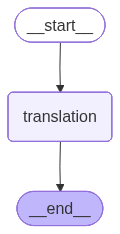

In [44]:
sub_graph = StateGraph(SubGraphState)
sub_graph.add_node('translation', translation)

sub_graph.add_edge(START, 'translation')
sub_graph.add_edge('translation', END)
sub_graph_workflow = sub_graph.compile()
sub_graph_workflow

In [45]:
class ParentState(TypedDict):
    question: str
    answer: str
    translated_hin: str
    

In [46]:
parent_model= ChatOpenAI(model='gpt-4o-mini')


In [47]:
def generate(state: ParentState):
    prompt = f"""
    Give the answer of the question - {state['question']}
    """
    result = parent_model.invoke(prompt).content
    return {'answer':result}

In [48]:
def translate_answer(state: ParentState):
    result=sub_graph_workflow.invoke({'answer_eng': state['answer']})
    return {'translated_hin': result['translated_text']}

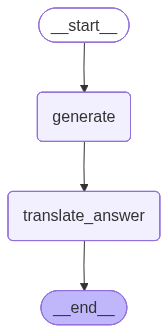

In [49]:
graph = StateGraph(ParentState)
graph.add_node('translate_answer', translate_answer)
graph.add_node('generate', generate)
graph.add_edge(START, 'generate')
graph.add_edge( 'generate', 'translate_answer')
graph.add_edge('translate_answer', END)
graph_workflow = graph.compile()
graph_workflow

In [50]:
init_state={
    'question': 'What is an atom?'
}

out= graph_workflow.invoke(init_state)
print(out)

{'question': 'What is an atom?', 'answer': 'An atom is the basic unit of matter and the defining structure of elements. It consists of a nucleus made up of protons and neutrons, surrounded by a cloud of electrons that orbit the nucleus. Protons carry a positive charge, neutrons are neutral, and electrons carry a negative charge. The arrangement and number of these subatomic particles distinguish one element from another and determine its chemical properties. Atoms can combine with other atoms to form molecules, which are the building blocks of all substances.', 'translated_hin': 'एक परमाणु पदार्थ की मूल इकाई है और तत्वों की परिभाषित संरचना है। इसमें प्रोटॉन और न्यूट्रॉन से बना एक नाभिक होता है, जिसे नाभिक के चारों ओर की इलेक्ट्रॉनों की एक बादल द्वारा घेर लिया जाता है। प्रोटॉन में सकारात्मक चार्ज होता है, न्यूट्रॉन तटस्थ होते हैं, और इलेक्ट्रॉन में नकारात्मक चार्ज होता है। इन उप-परमाणु कणों की व्यवस्था और संख्या एक तत्व को दूसरे से अलग करती है और इसकी रासायनिक गुणों को निर्धारित करती है